<a href="https://colab.research.google.com/github/dwimanuputty/PENGOLAHAN-CITRA-DIGITAL/blob/main/pengolahancitradigital.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import cv2

# Matriks biner

data = np.array([
  [0,0,0,0,0,0,0,0,0],
  [0,1,1,1,0,0,0,1,1],
  [0,1,1,1,0,0,0,1,1],
  [0,0,0,0,0,0,0,0,0],
  [0,0,0,0,0,0,0,0,0],
  [0,0,1,1,0,1,1,1,0],
  [0,0,1,1,0,1,1,1,0],
  [0,0,0,0,0,0,0,0,0],
  [0,0,0,0,0,0,0,0,0],
  ], dtype=np.uint8)

# Connected componemts dengan 4-connectivity

num_labels, labels = cv2.connectedComponents(data, connectivity=4)
print("Jumlah objek:", num_labels-1) # dikurangi 1 karena background dihitung juga

Jumlah objek: 4


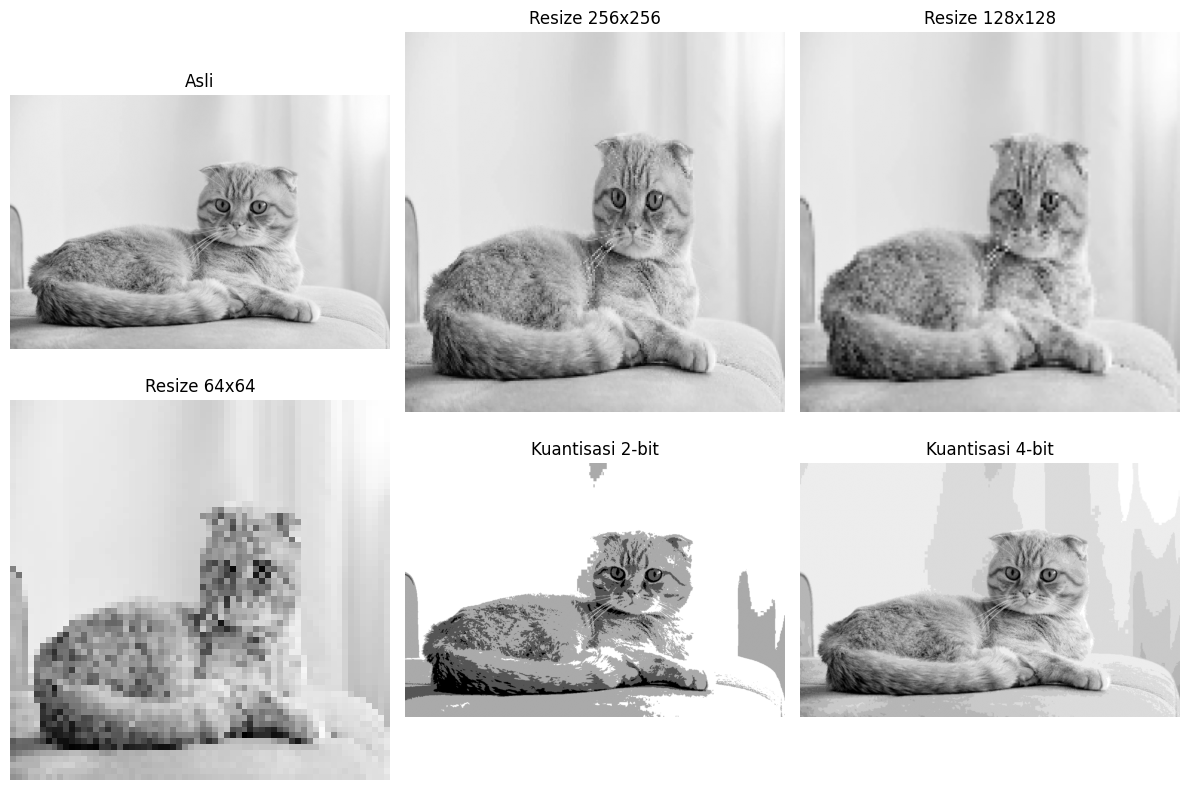

In [8]:
import cv2
import matplotlib.pyplot as plt

# Baca gambar (pastikan file kucing.jpeg ada di folder kerja)
img = cv2.imread("kucing.jpeg", cv2.IMREAD_GRAYSCALE)

# Cek apakah gambar terbaca
if img is None:
    print("File kucing.jpeg tidak ditemukan. Pastikan nama dan lokasi file benar.")
else:
    # Resize bertahap
    img_256 = cv2.resize(img, (256,256), interpolation=cv2.INTER_NEAREST)
    img_128 = cv2.resize(img, (128,128), interpolation=cv2.INTER_NEAREST)
    img_64  = cv2.resize(img, (64,64), interpolation=cv2.INTER_NEAREST)

    # Kuantisasi grayscale
    img_2bit = (img // 64) * 64   # 4 level
    img_4bit = (img // 16) * 16   # 16 level
    img_8bit = img.copy()         # 256 level (asli)

    # Tampilkan semua hasil
    plt.figure(figsize=(12,8))

    plt.subplot(2,3,1); plt.imshow(img, cmap='gray'); plt.title("Asli"); plt.axis("off")
    plt.subplot(2,3,2); plt.imshow(img_256, cmap='gray'); plt.title("Resize 256x256"); plt.axis("off")
    plt.subplot(2,3,3); plt.imshow(img_128, cmap='gray'); plt.title("Resize 128x128"); plt.axis("off")
    plt.subplot(2,3,4); plt.imshow(img_64, cmap='gray'); plt.title("Resize 64x64"); plt.axis("off")
    plt.subplot(2,3,5); plt.imshow(img_2bit, cmap='gray'); plt.title("Kuantisasi 2-bit"); plt.axis("off")
    plt.subplot(2,3,6); plt.imshow(img_4bit, cmap='gray'); plt.title("Kuantisasi 4-bit"); plt.axis("off")

    plt.tight_layout()
    plt.show()

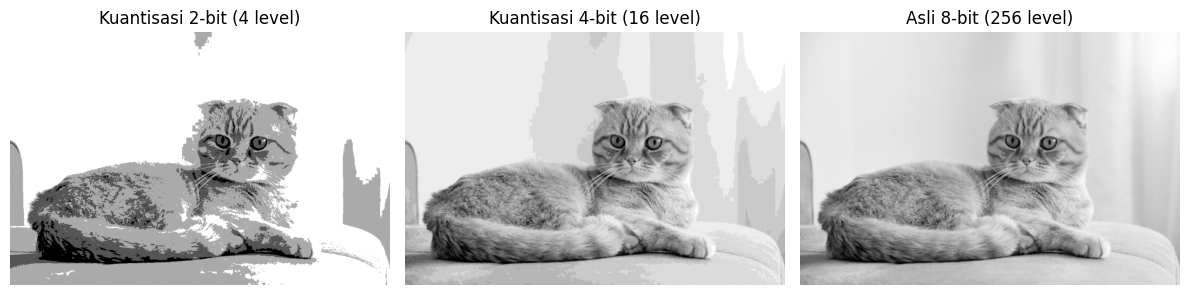

In [9]:
import cv2
import matplotlib.pyplot as plt

# Baca gambar grayscale
img = cv2.imread("kucing.jpeg", cv2.IMREAD_GRAYSCALE)

if img is None:
    print("File kucing.jpeg tidak ditemukan. Pastikan nama dan lokasi file benar.")
else:
    # Kuantisasi 2-bit (4 level)
    img_2bit = (img // 64) * 64

    # Kuantisasi 4-bit (16 level)
    img_4bit = (img // 16) * 16

    # Kuantisasi 8-bit (256 level) = asli
    img_8bit = img.copy()

    # Tampilkan hasil kuantisasi
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1); plt.imshow(img_2bit, cmap='gray'); plt.title("Kuantisasi 2-bit (4 level)"); plt.axis("off")
    plt.subplot(1,3,2); plt.imshow(img_4bit, cmap='gray'); plt.title("Kuantisasi 4-bit (16 level)"); plt.axis("off")
    plt.subplot(1,3,3); plt.imshow(img_8bit, cmap='gray'); plt.title("Asli 8-bit (256 level)"); plt.axis("off")

    plt.tight_layout()
    plt.show()